# <center>RandomForestClassifier</center>
<ul>
    <li>RandomForestClassifier: Es un Modelo de Aprendizaje Automático (supervisado): Es un modelo basado en arboles de deciciones.</li>
</ul>

# 1. Importamos las librerias a utilizar para nuestro modelo DecisionTreeClassifier

In [1]:
from sklearn.model_selection import GroupKFold, KFold, cross_validate, train_test_split, GridSearchCV,cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,precision_score, recall_score, f1_score
import pandas as pd
import numpy as np
# Librearias para el uso de graficas 
from pandas.plotting import scatter_matrix
from string import ascii_letters
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Importamos y visualizamos nuestro dataSet utilizando pandas 

In [2]:
data=pd.read_csv("data/dataSetpH.csv",encoding='latin-1')
data.head(2)

,SQUARE,PLOT,ANO,PH,LOI,C_CONC_LOI,C_STOCK_LOI,BULK_DENSITY,MOISTURE,N_PERCENT,N_STOCK,PO4_OLSEN,LC07,LC07_NUM,COUNTRY,COUNTY07,EZ_DESC_07,STATE_PH,STATE_NUMBER
0,AZFZMV,JQWCHLFHEI,2007,4.31,93.98097,516.895335,78.471725,0.101209,86.396896,NaN,NaN,NaN,31s,39,SCO,Shetland Islands,Intermediate uplands and Islands (Scotland),Fuertemenete Ácido,2.0
1,AZFZMV,TBVIDVQSYN,2007,4.26,95.67244,526.198420,105.353200,0.133477,83.977858,NaN,NaN,NaN,31s,39,SCO,Shetland Islands,Intermediate uplands and Islands (Scotland),Fuertemenete Ácido,2.0


# 3. Realizamos un análisis de nuestros conjuntos de datos para identificar posibles datos faltantes o excedentes.

In [3]:
data.isnull().sum()

SQUARE             0
PLOT               0
ANO                0
PH                 1
LOI               31
C_CONC_LOI        31
C_STOCK_LOI       75
BULK_DENSITY      75
MOISTURE          50
N_PERCENT       1641
N_STOCK         1655
PO4_OLSEN       1601
LC07               0
LC07_NUM           0
COUNTRY            0
COUNTY07           0
EZ_DESC_07         0
STATE_PH           1
STATE_NUMBER       1
dtype: int64

# 4. Eliminamos nuestros datos faltantes para que estén limpios y listos para su análisis

In [4]:
data.dropna(subset=["PH", "STATE_PH","STATE_NUMBER"], inplace=True)
data['STATE_PH_INT'] = data['STATE_NUMBER'].astype(int)

In [5]:
datos_asc = data.sort_values("PH", ascending=True)  # ordenamos nuestros datos de menor a mayor 
x_asc = datos_asc[["PH"]]
y_asc = datos_asc["STATE_PH_INT"]
datos_asc.head(2)

,SQUARE,PLOT,ANO,PH,LOI,C_CONC_LOI,C_STOCK_LOI,BULK_DENSITY,MOISTURE,N_PERCENT,N_STOCK,PO4_OLSEN,LC07,LC07_NUM,COUNTRY,COUNTY07,EZ_DESC_07,STATE_PH,STATE_NUMBER,STATE_PH_INT
304,HIZWNL,MIOUKRJLOG,2007,3.31,89.361920,491.490560,95.759693,0.129890,84.964290,NaN,NaN,NaN,19e,21,ENG,Northumberland,Uplands (England),Extremadamente Ácido,1.0,1
1070,KLOORS,GPVDGZNSYG,2007,3.32,7.527621,41.401916,56.058643,0.902674,34.730047,0.22,2.978824,3.0,6w,42,WAL,West Glamorgan,Lowlands (Wales),Extremadamente Ácido,1.0,1


# 5. Entrenamos nuestro modelo con los datos optmizados para nuestro modelo de DecisionTreeClassifier

In [6]:
x_train,x_test,y_train,y_test=train_test_split(x_asc,y_asc,test_size=0.25, random_state=42)
model = RandomForestClassifier(n_estimators=100, random_state=42)
#model = RandomForestClassifier(n_jobs=2, random_state=0)

In [7]:
model.fit(x_train,y_train)
predict=model.predict(x_test)

accuracy=accuracy_score(y_test,predict)

In [8]:
valores_PH = [4.5, 6.3, 7.02, 8.1, 9]
nuevos_datos = pd.DataFrame({'PH': valores_PH})
predicciones_nuevos_datos = model.predict(nuevos_datos)
print(f"Tasa acierto de nuestro modelo es de: {round(accuracy*100,2)} %")
print("Predicciones segun el pH:")
for ph, pred in zip(valores_PH, predicciones_nuevos_datos):
    print(f"PH: {ph}, Clasificación: {pred}")

Tasa acierto de nuestro modelo es de: 99.85 %
Predicciones segun el pH:
PH: 4.5, Clasificación: 2
PH: 6.3, Clasificación: 4
PH: 7.02, Clasificación: 5
PH: 8.1, Clasificación: 7
PH: 9, Clasificación: 7


# 6. Ahora buscaremos optimizar nuestro modelo mediante la ajuste de parámetros, con el objetivo de obtener predicciones más realistas y acordes a nuestras necesidades.
* n_estimators: Número de árboles de decisión que se deben crear para el análisis de nuestro modelo. 
* En el siguiente código, buscaremos el número adecuado de nuestro n_estimators.

In [9]:
def train_random_forest(n_estimators, x_asc, y_asc, data):
    SEED = 301
    np.random.seed(SEED)

    cv = GroupKFold(n_splits=8)
    modelo = RandomForestClassifier(n_estimators=n_estimators)
    results = cross_validate(modelo, x_asc, y_asc, cv=cv, groups=data.STATE_PH_INT, return_train_score=True)
    
    train_score = results['train_score'].mean() * 100
    test_score = results['test_score'].mean() * 100
    print('Random Forest n_estimators = %d, training = %.2f, testing = %.2f' % (n_estimators, train_score, test_score))
     
    tabla = [n_estimators, round(train_score, 2), round(test_score, 2)]
    return tabla


In [10]:
def main():
    resultados_df = [
        train_random_forest(n_estimators=i, x_asc=x_asc, y_asc=y_asc, data=data)
        for i in range(1, 30)
        for j in range(1, 10) 
    ]

    resultados_df = pd.DataFrame(resultados_df, columns=['n_estimators', 'train', 'test'])
    print(f"\n")
    return {'table': resultados_df.head(len(resultados_df)), 'result': resultados_df}


In [11]:
result_main = main()                       #  los resultados optimos para establecer nuestro n_estimators estan en :  
value_table = result_main['table']        #   9,10,11,19,20,21,22,23,24,25,26,27
value_table                              #    tienen un test_score de 99.95

Random Forest n_estimators = 1, training = 99.97, testing = 99.90
Random Forest n_estimators = 1, training = 99.97, testing = 99.90
Random Forest n_estimators = 1, training = 99.97, testing = 99.90
Random Forest n_estimators = 1, training = 99.97, testing = 99.90
Random Forest n_estimators = 1, training = 99.97, testing = 99.90
Random Forest n_estimators = 1, training = 99.97, testing = 99.90
Random Forest n_estimators = 1, training = 99.97, testing = 99.90
Random Forest n_estimators = 1, training = 99.97, testing = 99.90
Random Forest n_estimators = 1, training = 99.97, testing = 99.90
Random Forest n_estimators = 2, training = 99.95, testing = 99.93
Random Forest n_estimators = 2, training = 99.95, testing = 99.93
Random Forest n_estimators = 2, training = 99.95, testing = 99.93
Random Forest n_estimators = 2, training = 99.95, testing = 99.93
Random Forest n_estimators = 2, training = 99.95, testing = 99.93
Random Forest n_estimators = 2, training = 99.95, testing = 99.93
Random For

,n_estimators,train,test
0,1,99.97,99.90
1,1,99.97,99.90
2,1,99.97,99.90
3,1,99.97,99.90
4,1,99.97,99.90
...,...,...,...
256,29,99.99,99.95
257,29,99.99,99.95
258,29,99.99,99.95
259,29,99.99,99.95


<AxesSubplot:xlabel='n_estimators', ylabel='train'>

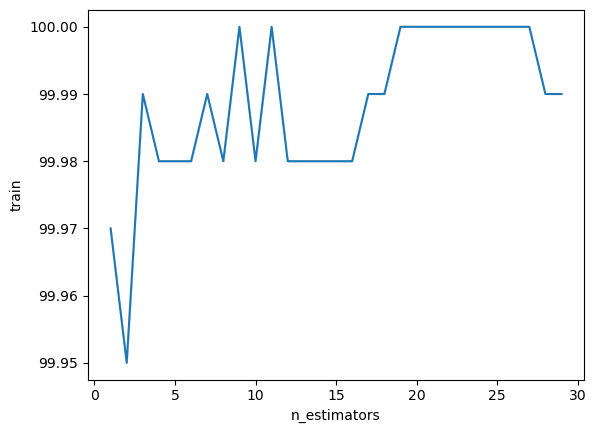

In [12]:
sns.lineplot(x='n_estimators', y='train', data=result_main['result'])

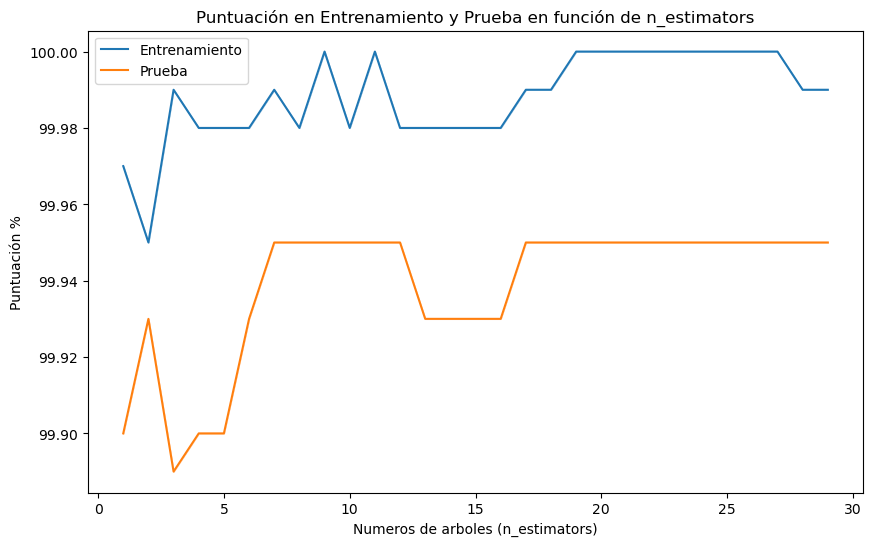

In [13]:
plt.figure(figsize=(10, 6))
sns.lineplot(x='n_estimators', y='train', data=result_main['result'], label='Entrenamiento')
sns.lineplot(x='n_estimators', y='test', data=result_main['result'], label='Prueba')
plt.xlabel('Numeros de arboles (n_estimators)')
plt.ylabel('Puntuación %')
plt.title('Puntuación en Entrenamiento y Prueba en función de n_estimators')

plt.legend()
plt.show()

# 7. A continuación, continuamos explorando parámetros para la optimización de nuestro código. En esta ocasión, añadiremos 'max_depth' como un parámetro a nuestro DecisionTreeClassifier.
* max_depth: Profundidad máxima de los árboles de decisión. Este hiperparámetro nos permite controlar la profundidad. Puede ser un número grande o pequeño; sin embargo, si el número es lo suficientemente grande, puede conducir a un sobreajuste de los datos  

In [14]:
def train_random_forest(n_estimators, max_depth, x_asc, y_asc, data):
    SEED = 301
    np.random.seed(SEED)

    cv = GroupKFold(n_splits=8)
    modelo = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth, random_state=SEED)
    results = cross_validate(modelo, x_asc, y_asc, cv=cv, groups=data.STATE_PH_INT, return_train_score=True)
    
    train_score = results['train_score'].mean() * 100
    test_score = results['test_score'].mean() * 100
    
    print('Random Forest n_estimators = %d, max_depth = %d, training = %.2f, testing = %.2f' % (n_estimators, max_depth, train_score, test_score))

    tabla = [n_estimators, max_depth, round(train_score, 2), round(test_score, 2)]
    return tabla


In [15]:
def main():
    resultados_df = [
        train_random_forest(n_estimators=i, max_depth=j, x_asc=x_asc, y_asc=y_asc, data=data)
        for i in range(1, 30)
        for j in range(1, 10)  # Puedes ajustar el rango de max_depth según tus necesidades
    ]

    resultados_df = pd.DataFrame(resultados_df, columns=['n_estimators', 'max_depth', 'train', 'test'])
    print(f"\n")
    return {'table': resultados_df.head(len(resultados_df)), 'result': resultados_df}


In [16]:
result1 = main()                       #  los resultados optimos para establecer nuestro n_estimators  y max_depth estan en :  
value_table1 = result1['table']       #  n_estimators = 5 y max_depth=5
value_table1    

Random Forest n_estimators = 1, max_depth = 1, training = 49.61, testing = 55.16
Random Forest n_estimators = 1, max_depth = 2, training = 70.73, testing = 73.05
Random Forest n_estimators = 1, max_depth = 3, training = 84.09, testing = 83.30
Random Forest n_estimators = 1, max_depth = 4, training = 94.75, testing = 95.36
Random Forest n_estimators = 1, max_depth = 5, training = 99.92, testing = 99.79
Random Forest n_estimators = 1, max_depth = 6, training = 99.95, testing = 99.79
Random Forest n_estimators = 1, max_depth = 7, training = 99.95, testing = 99.79
Random Forest n_estimators = 1, max_depth = 8, training = 99.95, testing = 99.79
Random Forest n_estimators = 1, max_depth = 9, training = 99.95, testing = 99.79
Random Forest n_estimators = 2, max_depth = 1, training = 49.61, testing = 55.16
Random Forest n_estimators = 2, max_depth = 2, training = 70.73, testing = 73.05
Random Forest n_estimators = 2, max_depth = 3, training = 85.73, testing = 85.40
Random Forest n_estimators =

,n_estimators,max_depth,train,test
0,1,1,49.61,55.16
1,1,2,70.73,73.05
2,1,3,84.09,83.30
3,1,4,94.75,95.36
4,1,5,99.92,99.79
...,...,...,...,...
256,29,5,99.96,99.95
257,29,6,99.99,99.95
258,29,7,99.99,99.95
259,29,8,99.99,99.95


In [21]:
corr1 = value_table1.corr()
corr1

,n_estimators,max_depth,train,test
n_estimators,1.000000e+00,8.443473e-17,0.002557,0.003566
max_depth,8.443473e-17,1.000000e+00,0.824266,0.834072
train,2.556726e-03,8.242664e-01,1.000000,0.999039
test,3.565956e-03,8.340724e-01,0.999039,1.000000


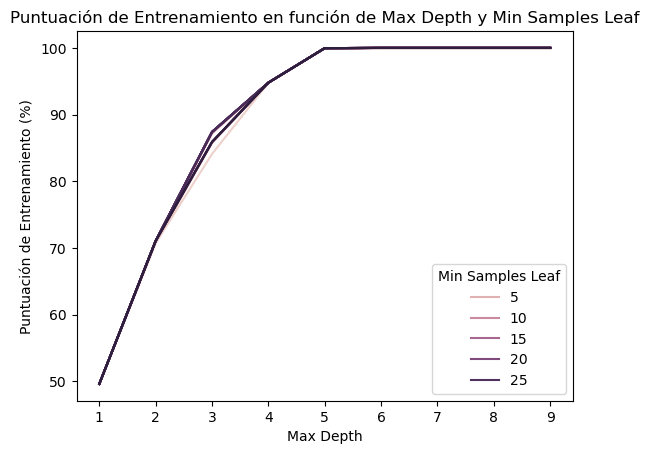

In [19]:
sns.lineplot(data=value_table1, x='max_depth', y='train', hue='n_estimators')
#sns.lineplot(data=result1, x='max_depth', y='test', hue='min_samples_leaf')
plt.title('Puntuación de Entrenamiento en función de Max Depth y Min Samples Leaf')
plt.xlabel('Max Depth')
plt.ylabel('Puntuación de Entrenamiento (%)')
plt.legend(title='Min Samples Leaf')
plt.show()

# 8. Explorando 3 dimensiones de hiper parámetros

In [20]:
def train_random_forest(n_estimators, max_depth, min_samples_leaf, x_asc, y_asc, data):
    SEED = 301
    np.random.seed(SEED)

    cv = GroupKFold(n_splits=8)
    modelo = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth, min_samples_leaf=min_samples_leaf)  # Usar RandomForestClassifier
    results = cross_validate(modelo, x_asc, y_asc, cv=cv, groups=data.STATE_PH_INT, return_train_score=True)
    
    train_score = results['train_score'].mean() * 100
    test_score = results['test_score'].mean() * 100
    
    print('Random Forest n_estimators = %d, max_depth = %d, min_samples_leaf = %d, training = %.2f, testing = %.2f' % (n_estimators, max_depth, min_samples_leaf, train_score, test_score))
    tabla = [n_estimators, max_depth, min_samples_leaf, train_score, test_score]
    return tabla

def search_best_result(x_asc, y_asc, data):
    resultados = []
    for n_estimators in [50, 100, 200]:  # Ajustar el número de estimadores
        for max_depth in range(1, 11):  # Ajustar la profundidad máxima
            for min_samples_leaf in [32, 64, 128, 256]:  # Ajustar el número mínimo de muestras en las hojas
                tabla = train_random_forest(n_estimators, max_depth, min_samples_leaf, x_asc, y_asc, data)
                resultados.append(tabla)
            
    resultados = pd.DataFrame(resultados, columns=['n_estimators', 'max_depth', 'min_samples_leaf', 'train', 'test'])
    print(len(resultados))
    return resultados.head(50)

result2 = search_best_result(x_asc, y_asc, data)
  # los mejores resultados en base a los hiperparametros proporcionados estan: 
 #  n _estimators = 10 , max_depth = 4 , min_samples_leaf = 32
#   con una porcentaje de acierto de 95.45


Random Forest n_estimators = 50, max_depth = 1, min_samples_leaf = 32, training = 49.61, testing = 55.16
Random Forest n_estimators = 50, max_depth = 1, min_samples_leaf = 64, training = 49.61, testing = 55.16
Random Forest n_estimators = 50, max_depth = 1, min_samples_leaf = 128, training = 49.61, testing = 55.16
Random Forest n_estimators = 50, max_depth = 1, min_samples_leaf = 256, training = 49.61, testing = 55.16
Random Forest n_estimators = 50, max_depth = 2, min_samples_leaf = 32, training = 71.05, testing = 73.44
Random Forest n_estimators = 50, max_depth = 2, min_samples_leaf = 64, training = 71.05, testing = 73.44
Random Forest n_estimators = 50, max_depth = 2, min_samples_leaf = 128, training = 69.21, testing = 71.67
Random Forest n_estimators = 50, max_depth = 2, min_samples_leaf = 256, training = 64.10, testing = 67.63
Random Forest n_estimators = 50, max_depth = 3, min_samples_leaf = 32, training = 84.40, testing = 85.16
Random Forest n_estimators = 50, max_depth = 3, min

In [22]:
corr2 = result2.corr()
corr2

,n_estimators,max_depth,min_samples_leaf,train,test
n_estimators,1.000000,-0.496030,-0.067532,-0.470871,-0.477708
max_depth,-0.496030,1.000000,0.019918,0.759441,0.760355
min_samples_leaf,-0.067532,0.019918,1.000000,-0.294512,-0.307373
train,-0.470871,0.759441,-0.294512,1.000000,0.999268
test,-0.477708,0.760355,-0.307373,0.999268,1.000000


In [ ]:
result2.sort_values('test', ascending = False).head()

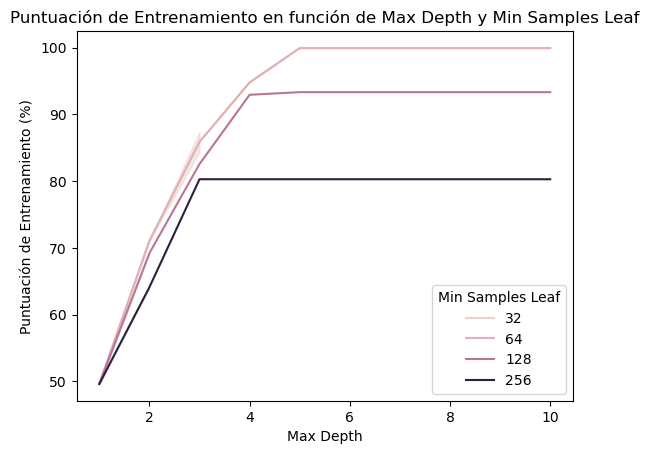

In [23]:
sns.lineplot(data=result2, x='max_depth', y='train', hue='min_samples_leaf')
#sns.lineplot(data=result1, x='max_depth', y='test', hue='min_samples_leaf')
plt.title('Puntuación de Entrenamiento en función de Max Depth y Min Samples Leaf')
plt.xlabel('Max Depth')
plt.ylabel('Puntuación de Entrenamiento (%)')
plt.legend(title='Min Samples Leaf')
plt.show()

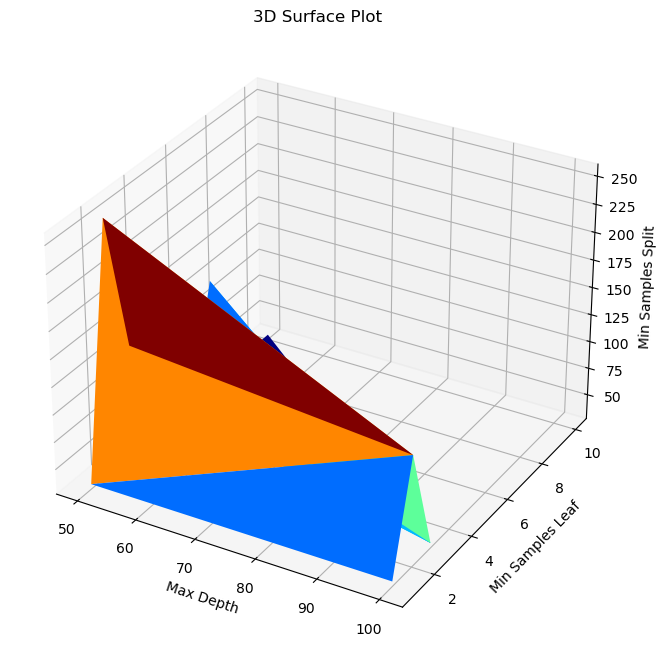

In [24]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def plot_3d_surface(df, x, y, z, xlabel, ylabel, zlabel, title):
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    x_values = df[x]
    y_values = df[y]
    z_values = df[z]
    
    #ax.plot_trisurf(x_values, y_values, z_values, cmap='viridis')
    #ax.plot_trisurf(x_values, y_values, z_values, cmap='coolwarm')
    #ax.plot_trisurf(x_values, y_values, z_values, cmap='plasma')
    #ax.plot_trisurf(x_values, y_values, z_values, cmap='inferno')
    ax.plot_trisurf(x_values, y_values, z_values, cmap='jet')

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_zlabel(zlabel)
    ax.set_title(title)
    
    plt.show()

plot_3d_surface(result2, 'n_estimators', 'max_depth', 'min_samples_leaf', 'Max Depth', 'Min Samples Leaf', 'Min Samples Split', '3D Surface Plot') 

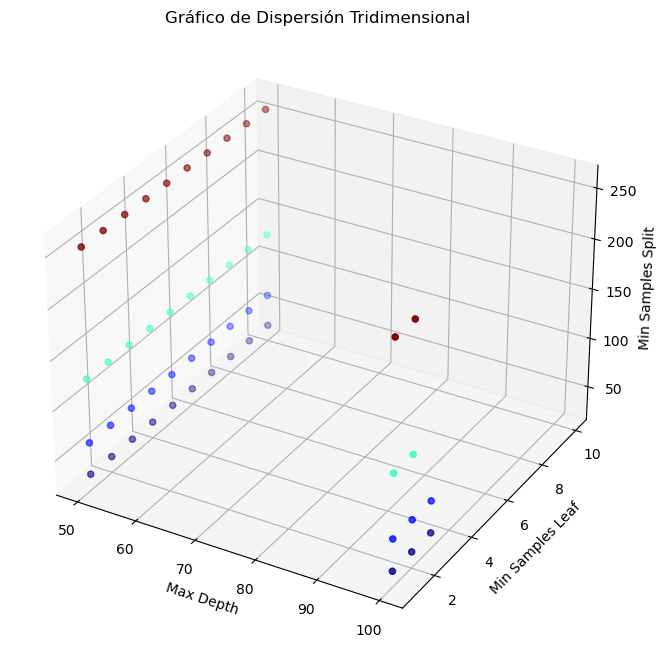

In [25]:
x = result2['n_estimators']
y = result2['max_depth']
z = result2['min_samples_leaf']

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Crear un gráfico de dispersión tridimensional
ax.scatter(x, y, z, c=z, cmap='jet')

# Etiquetas de los ejes y título
ax.set_xlabel('Max Depth')
ax.set_ylabel('Min Samples Leaf')
ax.set_zlabel('Min Samples Split')
ax.set_title('Gráfico de Dispersión Tridimensional')

plt.show()


<Figure size 800x500 with 0 Axes>

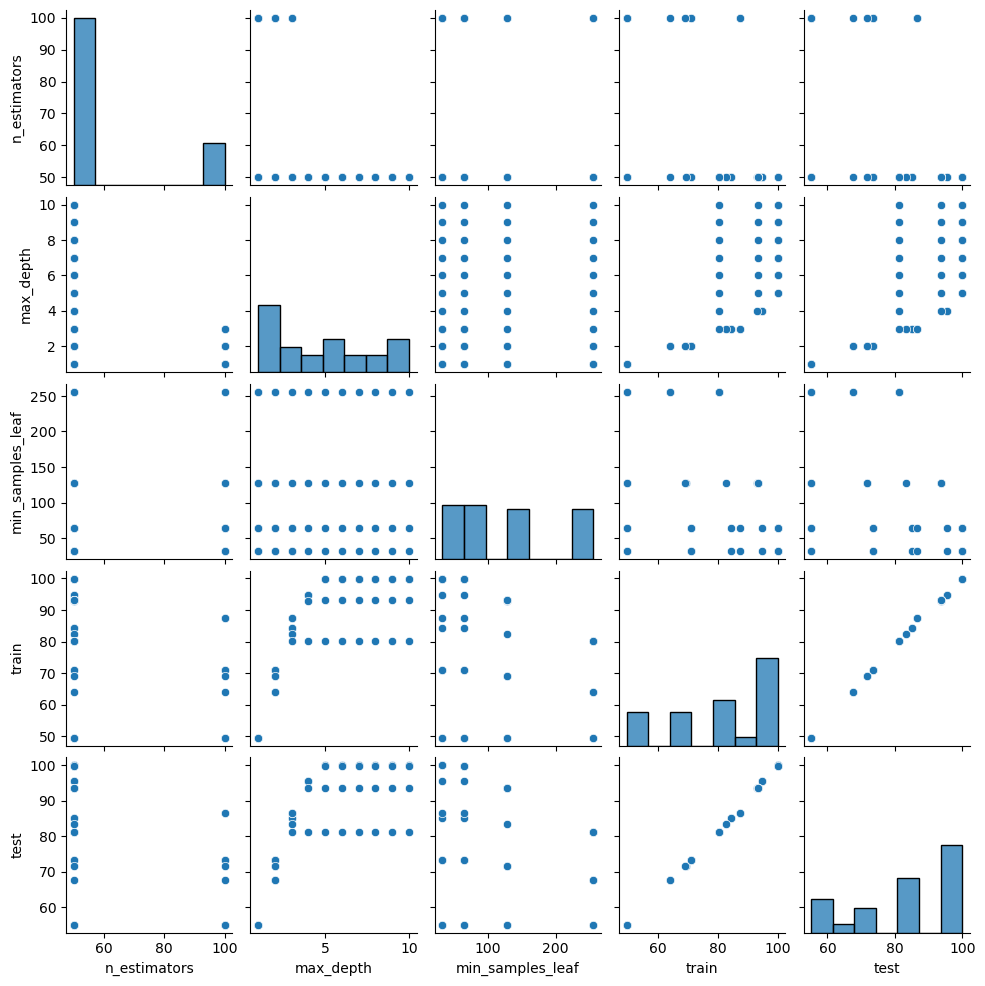

In [26]:
plt.figure(figsize=(8, 5))
sns.pairplot(result2, height=2, aspect=1)
plt.show()

# 9. Explorando 4 dimensiones de hiperparámetros utilizando GridSearchCV

In [27]:
SEED = 301
np.random.seed(SEED)

espacio_de_parametros = {
    'n_estimators':[50, 100, 200],
    'max_depth' : [3,5],
    'min_samples_split' : [32,64,128],
    'min_samples_leaf' : [32,64,128],
    'criterion' : ['gini', 'entropy']
}

search_end = GridSearchCV(RandomForestClassifier(),
                      espacio_de_parametros,
                      cv = KFold(n_splits = 5, shuffle=True))

search_end.fit(x_asc, y_asc)
resultados = pd.DataFrame(search_end.cv_results_)
resultados.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_criterion,param_max_depth,param_min_samples_leaf,param_min_samples_split,param_n_estimators,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.144800,0.029053,0.015607,0.012039,gini,3,32,32,50,"{'criterion': 'gini', 'max_depth': 3, 'min_sam...",0.862004,0.84121,0.846881,0.829868,0.842803,0.844553,0.010391,82
1,0.238620,0.032990,0.012188,0.002042,gini,3,32,32,100,"{'criterion': 'gini', 'max_depth': 3, 'min_sam...",0.862004,0.84121,0.846881,0.829868,0.842803,0.844553,0.010391,82
2,0.415527,0.028832,0.026003,0.009811,gini,3,32,32,200,"{'criterion': 'gini', 'max_depth': 3, 'min_sam...",0.862004,0.84121,0.846881,0.829868,0.842803,0.844553,0.010391,82
3,0.091024,0.006334,0.005803,0.000406,gini,3,32,64,50,"{'criterion': 'gini', 'max_depth': 3, 'min_sam...",0.862004,0.84121,0.846881,0.829868,0.842803,0.844553,0.010391,82
4,0.202101,0.004927,0.010797,0.000415,gini,3,32,64,100,"{'criterion': 'gini', 'max_depth': 3, 'min_sam...",0.862004,0.84121,0.846881,0.829868,0.842803,0.844553,0.010391,82


In [28]:
scores = cross_val_score(search_end, x_asc, y_asc, cv = KFold(n_splits=5, shuffle=True))
scores

array([0.99810964, 1.        , 1.        , 1.        , 1.        ])

In [29]:
mejor_estimator = search_end.best_estimator_
def print_score(scores):
  media = scores.mean() * 100
  desviacion = scores.std() * 100
  print("Accuracy media %.2f" % media)
  print("Intervalo [%.2f, %.2f]" % (media - 2 * desviacion, media + 2 * desviacion))
  print(search_end.best_params_)
  print(mejor_estimator)
  print(round(search_end.best_score_ * 100,2))
    
print_score(scores)

Accuracy media 99.96
Intervalo [99.81, 100.11]
{'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 32, 'min_samples_split': 32, 'n_estimators': 100}
RandomForestClassifier(max_depth=5, min_samples_leaf=32, min_samples_split=32)
99.96


In [30]:
prediccion = mejor_estimator.predict(x_asc)
accuracy = accuracy_score(prediccion, y_asc) * 100
print('Accuracy para los datos fue %.2f%% ' % accuracy)

Accuracy para los datos fue 99.96% 


# 10. Codigo final de nuestro modelo DecisionTreeClassifier

In [31]:
x_train_,x_test_,y_train_,y_test_=train_test_split(x_asc,y_asc,test_size=0.25,random_state=SEED)

best_params={
    'max_depth':5,
    'min_samples_split':32,
    'min_samples_leaf':32,
    'criterion':'gini'
}    

modelo=RandomForestClassifier(**best_params)

modelo.fit(x_test_,y_test_)

y_predict=modelo.predict(x_test_)
accuracy=modelo.score(x_test_,y_test_)

print(f"Exactitud en datos de prueba {round(accuracy*100,2)} %")

Exactitud en datos de prueba 95.92 %


### A continuación, evaluaremos nuestro modelo utilizando las siguientes métricas de clasificación: accuracy_score, precisión, recall y F1-Score. El objetivo es determinar el nivel de precisión de los resultados obtenidos por nuestro modelo entrenado y optimizado con los parámetros evaluados durante el entrenamiento.

In [32]:
accuracy_score_end = accuracy_score(y_test_, y_predict)
precision = precision_score(y_test_, y_predict,average='macro')
recall = recall_score(y_test_, y_predict,average='macro')
f1 = f1_score(y_test_, y_predict,average='macro')

print(f"Exactitud en datos de prueba con accuracy_score: {round(accuracy_score_end * 100, 2)} %")
print(f'Accuracy: {round(accuracy_score_end*100,2)}')
print(f'Precision: {round(precision*100,2)}')
print(f'Recall: {round(recall*100,2)}')
print(f'F1-Score: {round(f1*100,2)}')

Exactitud en datos de prueba con accuracy_score: 95.92 %
Accuracy: 95.92
Precision: 81.43
Recall: 85.71
F1-Score: 83.19


C:\Users\Rumijsd\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


#### Resultado finl de evaluación de nuestro modelo en base a las métricas mencionadas en un dataFrame

In [33]:
results_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Value': [round(accuracy_score_end*100,2), round(precision*100,2), round(recall*100,2), round(f1*100,2)]
})

results_df

,Metric,Value
0,Accuracy,95.92
1,Precision,81.43
2,Recall,85.71
3,F1-Score,83.19


# 11. Realizando pruebas finales 

In [34]:
x_data = [[3.0],[8.0],[0.9]]  # Datos para la predicción
phData = modelo.predict(x_data)
print(f"{phData}")

dt_stateString = pd.DataFrame(datos_asc)
pH_group_by = dt_stateString.groupby(['STATE_PH', 'STATE_PH_INT'])

for (ph, state_ph_int), group_data in pH_group_by:
    for pred in phData:
        if pred==state_ph_int:
             print(f"predicción: {ph} estado {state_ph_int}")

[1 7 1]
predicción: Extremadamente Ácido estado 1
predicción: Extremadamente Ácido estado 1
predicción: Moderadamente Alcalino estado 7


C:\Users\Rumijsd\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
